---
# 1. Carregamento do dataset + Tratamento inicial

In [ ]:
# ================================
# 1. Upload do arquivo no Colab
# ================================
from google.colab import files
uploaded = files.upload()

# O Colab salva o arquivo no diretório atual.
# Pegamos automaticamente o nome do arquivo enviado:
import pandas as pd

nome_arquivo = list(uploaded.keys())[0]
print("Arquivo carregado:", nome_arquivo)

# ================================
# 2. Carregar dataset
# ================================
df = pd.read_csv(nome_arquivo)

# ================================
# 3. Renomear colunas para o padrão do sistema
# ================================
df = df.rename(columns={
    "job_title": "cargo",
    "experience_level": "nivel_experiencia",
    "employment_type": "tipo_contrato",
    "work_models": "modalidade",
    "salary_in_usd": "salario_usd",
    "employee_residence": "pais_residencia",
    "company_location": "pais_empresa",
    "company_size": "porte_empresa",
    "work_year": "ano"
})

# ================================
# 4. Limpeza básica
# ================================
df["cargo"] = df["cargo"].astype(str).str.strip()
df["modalidade"] = df["modalidade"].astype(str).str.strip()
df["nivel_experiencia"] = df["nivel_experiencia"].astype(str).str.strip()

# ================================
# 5. Visualizar primeiras linhas
# ================================
df.head()

Saving data_science_salaries.csv to data_science_salaries (1).csv
Arquivo carregado: data_science_salaries (1).csv


,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


---
# 2. Funções do Sistema (v3 – Pandas)

In [ ]:
import os

# Criar a pasta se não existir
os.makedirs("sistema", exist_ok=True)

# Conteúdo do arquivo funcoes.py
conteudo = """
import pandas as pd

def filtrar_por_cargo(df, cargo):
    return df[df["cargo"].str.contains(cargo, case=False, na=False)]

def salario_medio_por_nivel(df):
    return df.groupby("nivel_experiencia")["salario_usd"].mean().sort_values()

def salario_medio_por_modalidade(df):
    return df.groupby("modalidade")["salario_usd"].mean().sort_values()

def salario_medio_por_pais(df):
    return df.groupby("pais_residencia")["salario_usd"].mean().sort_values(ascending=False)

def vagas_por_cargo(df):
    return df["cargo"].value_counts()

def salario_medio_por_ano(df):
    return df.groupby("ano")["salario_usd"].mean()

def modalidade_por_ano(df):
    return df.groupby(["ano", "modalidade"]).size().unstack(fill_value=0)
"""

# Criar o arquivo
with open("sistema/funcoes.py", "w") as f:
    f.write(conteudo)

print("Arquivo sistema/funcoes.py criado com sucesso!")

Arquivo sistema/funcoes.py criado com sucesso!


---
# 3. Pergunta de Negócio 1 — Progressão salarial por nível de experiência



**Pergunta:** Qual é o salário médio em cada nível (EN, MI, SE, EX)? A
progressão é parecida entre os cargos principais (Data Analyst, Data Scientist, Data Engineer)?

### 🔹 Cálculo do salário médio por nível de experiência:





In [ ]:
# ================================
# Salário Médio por Nível de Experiência
# ================================

from sistema.funcoes import salario_medio_por_nivel

salarios_nivel = salario_medio_por_nivel(df)
print(salarios_nivel)

nivel_experiencia
Entry-level         84448.916814
Mid-level          119019.812537
Senior-level       162071.063581
Executive-level    189687.346457
Name: salario_usd, dtype: float64


<Axes: title={'center': 'Salário médio por nível de experiência'}, xlabel='nivel_experiencia'>

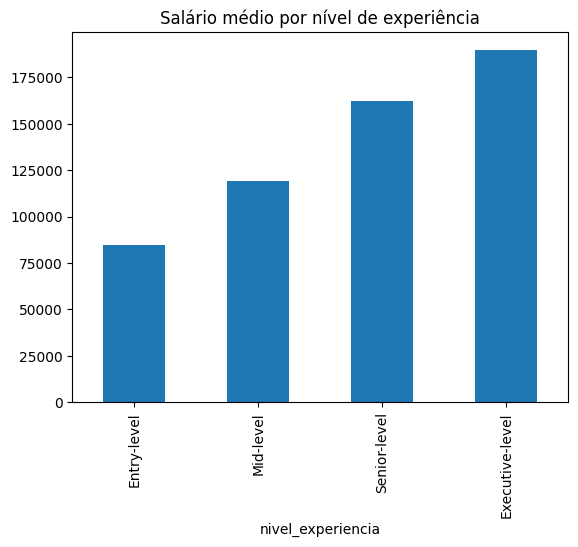

In [ ]:
# ================================
# Gráfico Comparativo
# ================================

salarios_nivel.plot(kind="bar", title="Salário médio por nível de experiência")

### 🔹 Análise da progressão salarial por nível de experiência e para os principais cargos:

<Axes: title={'center': 'Progressão salarial por nível e cargo'}, xlabel='nivel_experiencia', ylabel='Salário (USD)'>

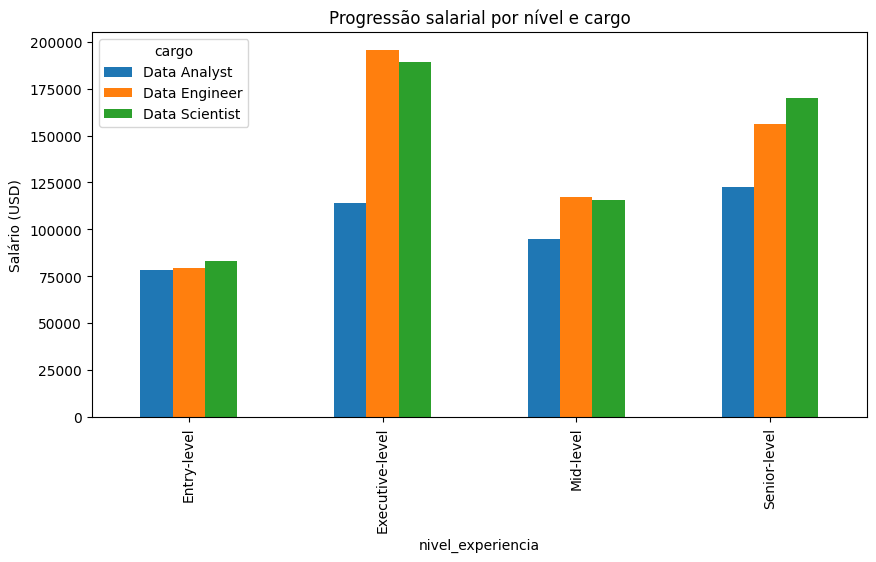

In [ ]:
# ================================
# Filtrar apenas os cargos principais
# ================================

cargos_principais = ["Data Analyst", "Data Scientist", "Data Engineer"]

df_cargos = df[df["cargo"].isin(cargos_principais)]

# ================================
# Calcular salário médio por nível e cargo
# ================================

salarios_cargo_nivel = df_cargos.groupby(["cargo", "nivel_experiencia"])["salario_usd"].mean().unstack()
salarios_cargo_nivel

# ================================
# Gráfico comparativo
# ================================

salarios_cargo_nivel.T.plot(kind="bar", figsize=(10,5), title="Progressão salarial por nível e cargo", ylabel="Salário (USD)")

➡️ **Resposta:** A progressão salarial não é igual entre os cargos.
Data Scientist e Data Engineer valorizam muito mais senioridade do que Data Analyst, que cresce de forma mais moderada.